In [52]:
# ==========================================
# 1. Install Libraries
# ==========================================

%pip install pandas matplotlib seaborn


# ==========================================
# 2. Import Libraries
# ==========================================

import os
import json
import glob

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [53]:
# ==========================================
# 3. Load JSON Dataset
# ==========================================

records = []

for file in glob.glob("data/*.json"):

    with open(file, "r", encoding="utf-8") as f:

        data = json.load(f)

        if isinstance(data, list):
            records.extend(data)

        else:
            records.append(data)


df = pd.DataFrame(records)


print("Total Records :", len(df))
print("Total Columns :", len(df.columns))


df.head()

Total Records : 201
Total Columns : 11


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status
0,2026-07-15T03:36:29.189Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,82.6,Connected
1,2026-07-15T04:03:39.028Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,132.0,Connected
2,2026-07-15T04:11:40.389Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,152.0,Connected
3,2026-07-15T14:28:08.741Z,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.4,Connected
4,2026-07-15T14:36:21.344Z,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.8,Connected


In [54]:
# ==========================================
# 4. Dataset Information
# ==========================================

print("Dataset Shape:", df.shape)

print("\nColumn Information")
df.info()

Dataset Shape: (201, 11)

Column Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        201 non-null    object 
 1   member_name      201 non-null    object 
 2   location_zone    201 non-null    object 
 3   provider         201 non-null    object 
 4   connection_type  201 non-null    object 
 5   public_ip        201 non-null    object 
 6   routing_region   201 non-null    object 
 7   is_vpn_active    201 non-null    bool   
 8   os_platform      201 non-null    object 
 9   latency_ms       185 non-null    float64
 10  status           201 non-null    object 
dtypes: bool(1), float64(1), object(9)
memory usage: 16.0+ KB


In [55]:
# ==========================================
# 5. Missing Values
# ==========================================

print("Missing Values")

df.isnull().sum()

Missing Values


timestamp           0
member_name         0
location_zone       0
provider            0
connection_type     0
public_ip           0
routing_region      0
is_vpn_active       0
os_platform         0
latency_ms         16
status              0
dtype: int64

In [56]:
# ==========================================
# 6. Data Cleaning
# ==========================================


# Remove missing latency

print("Before latency cleaning:", len(df))

df = df.dropna(subset=["latency_ms"])

print("After latency cleaning:", len(df))



# Remove duplicate records

print("\nDuplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()

print("After duplicate removal:", len(df))



# Remove Offline Network Records

print("\nBefore Offline removal:", len(df))


df = df[
    (df["provider"] != "Offline") &
    (df["connection_type"] != "Offline") &
    (df["routing_region"] != "None") &
    (df["public_ip"] != "None")
]


print("After Offline removal:", len(df))


df.head()

Before latency cleaning: 201
After latency cleaning: 185

Duplicate Records: 0
After duplicate removal: 185

Before Offline removal: 185
After Offline removal: 180


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status
0,2026-07-15T03:36:29.189Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,82.6,Connected
1,2026-07-15T04:03:39.028Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,132.0,Connected
2,2026-07-15T04:11:40.389Z,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,152.0,Connected
3,2026-07-15T14:28:08.741Z,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.4,Connected
4,2026-07-15T14:36:21.344Z,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.8,Connected


In [57]:
# ==========================================
# 7. Feature Engineering
# ==========================================


df["timestamp"] = pd.to_datetime(df["timestamp"])


df["date"] = df["timestamp"].dt.date

df["hour"] = df["timestamp"].dt.hour

df["weekday"] = df["timestamp"].dt.day_name()



df.head()

,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status,date,hour,weekday
0,2026-07-15 03:36:29.189000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,82.6,Connected,2026-07-15,3,Wednesday
1,2026-07-15 04:03:39.028000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,132.0,Connected,2026-07-15,4,Wednesday
2,2026-07-15 04:11:40.389000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,152.0,Connected,2026-07-15,4,Wednesday
3,2026-07-15 14:28:08.741000+00:00,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.4,Connected,2026-07-15,14,Wednesday
4,2026-07-15 14:36:21.344000+00:00,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.8,Connected,2026-07-15,14,Wednesday


In [58]:
# ==========================================
# 8. Numerical Statistics
# ==========================================

df.describe()

,latency_ms,hour
count,180.000000,180.000000
mean,197.297778,14.488889
std,321.439558,3.224364
min,43.000000,3.000000
25%,54.700000,14.000000
50%,82.200000,15.000000
75%,247.250000,16.000000
max,3335.000000,18.000000


In [59]:
# ==========================================
# 9. Category Analysis
# ==========================================


print("ISP Providers")
display(df["provider"].value_counts())


print("\nConnection Type")
display(df["connection_type"].value_counts())


print("\nOperating System")
display(df["os_platform"].value_counts())


print("\nRouting Region")
display(df["routing_region"].value_counts())


print("\nLocation Zone")
display(df["location_zone"].value_counts())


print("\nVPN Status")
display(df["is_vpn_active"].value_counts())

ISP Providers


provider
Mytel    180
Name: count, dtype: int64


Connection Type


connection_type
Wi-Fi    180
Name: count, dtype: int64


Operating System


...

routing_region
Bago Region      72
Yangon Region    41
Yangon           27
Mon              23
Mon State        17
Name: count, dtype: int64


Location Zone


location_zone
Mingalar Garden    144
Mingala Garden      33
Final Section B      3
Name: count, dtype: int64


VPN Status


is_vpn_active
False    180
Name: count, dtype: int64

In [60]:
# ==========================================
# 10. Final ISP Analysis Dataset
# ==========================================


isp_df = df.copy()


print("Final Analysis Records:", len(isp_df))

isp_df.head()

Final Analysis Records: 180


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status,date,hour,weekday
0,2026-07-15 03:36:29.189000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,82.6,Connected,2026-07-15,3,Wednesday
1,2026-07-15 04:03:39.028000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,132.0,Connected,2026-07-15,4,Wednesday
2,2026-07-15 04:11:40.389000+00:00,Aster Julian Ray,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,linux,152.0,Connected,2026-07-15,4,Wednesday
3,2026-07-15 14:28:08.741000+00:00,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.4,Connected,2026-07-15,14,Wednesday
4,2026-07-15 14:36:21.344000+00:00,Myo Min Aung,Mingalar Garden,Mytel,Wi-Fi,45.112.47.201,Mon,False,linux,48.8,Connected,2026-07-15,14,Wednesday


1.  provider
Mytel    180
Name: count, dtype: int64


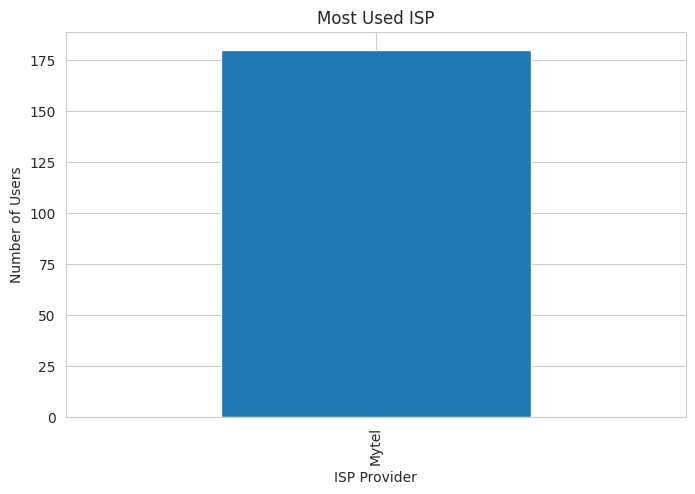

In [61]:
# ==========================================
# ISP Analysis Questions
# ==========================================
# 1. Which ISP is used the most?

isp_usage = isp_df["provider"].value_counts()

isp_usage
print("1. ", isp_usage)

plt.figure(figsize=(8,5))

isp_usage.plot(kind="bar")

plt.title("Most Used ISP")
plt.xlabel("ISP Provider")
plt.ylabel("Number of Users")

plt.show()

2. provider
Mytel    197.297778
Name: latency_ms, dtype: float64


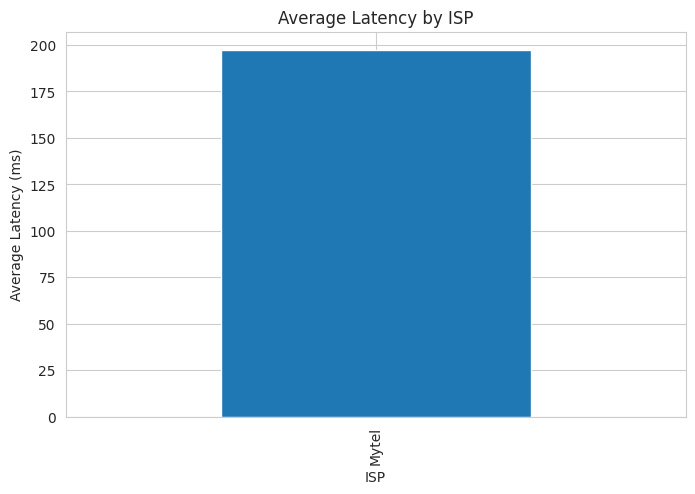

In [62]:
# 2. Which ISP has lowest average latency?

isp_latency = (
    isp_df
    .groupby("provider")["latency_ms"]
    .mean()
    .sort_values()
)

isp_latency
print("2.", isp_latency)

plt.figure(figsize=(8,5))

isp_latency.plot(kind="bar")

plt.title("Average Latency by ISP")
plt.xlabel("ISP")
plt.ylabel("Average Latency (ms)")

plt.show()

In [63]:
# 3. Which location has highest latency?

location_latency = (
    isp_df
    .groupby("location_zone")["latency_ms"]
    .mean()
    .sort_values(ascending=False)
)


location_latency

location_zone
Mingalar Garden    217.776389
Final Section B    122.200000
Mingala Garden     114.763636
Name: latency_ms, dtype: float64

In [64]:
# 4. How many users use VPN?
vpn_usage = isp_df["is_vpn_active"].value_counts()

vpn_usage

is_vpn_active
False    180
Name: count, dtype: int64

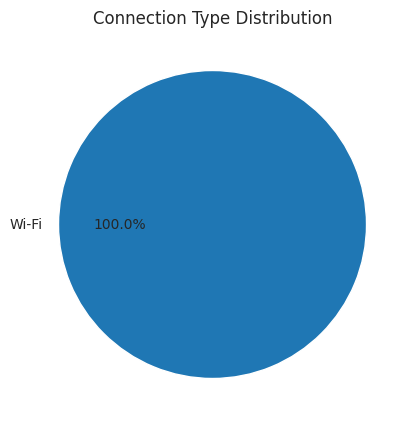

In [65]:
# 5. Wi-Fi vs Mobile Data Usage
connection_usage = isp_df["connection_type"].value_counts()

connection_usage

plt.figure(figsize=(7,5))

connection_usage.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Connection Type Distribution")

plt.ylabel("")

plt.show()

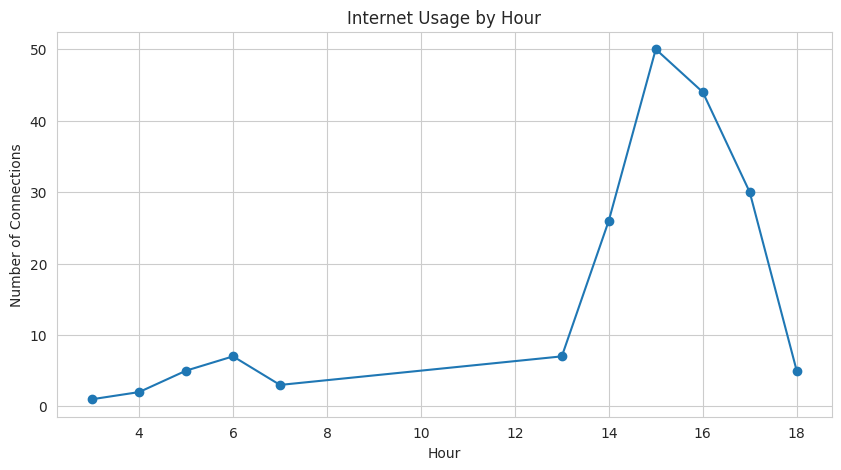

In [66]:
# 6. At what hour is internet used most?
hour_usage = (
    isp_df["hour"]
    .value_counts()
    .sort_index()
)


hour_usage
plt.figure(figsize=(10,5))

hour_usage.plot(kind="line", marker="o")


plt.title("Internet Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Connections")


plt.show()

In [67]:
# 7. Most Frequent Routing Region

routing_usage = isp_df["routing_region"].value_counts()

routing_usage

routing_region
Bago Region      72
Yangon Region    41
Yangon           27
Mon              23
Mon State        17
Name: count, dtype: int64

In [68]:
# 8. Most Common OS Platform
os_usage = isp_df["os_platform"].value_counts()

os_usage

os_platform
linux    180
Name: count, dtype: int64